# Study how calorimeter decay shower truth is processed

In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("../")
from pyedm4hep import EDM4hepEvent

In [5]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

In [6]:
base_dir = "/global/cfs/projectdirs/m4958/data/ColliderML/outputs/single_particle_tests/"
event_num = 0

This is with the TC truth handler turned on, but with a tracker the size of the world volume. That is, we should see energy threshold effects, but not calorimeter decay collapse effects.

In [7]:
edm4hep_file = f"{base_dir}/single_run_test_ODD_low_threshold/edm4hep.root"
low_event = EDM4hepEvent(edm4hep_file, event_index=event_num, detector_params=detector_params)

Loading event 0 from /global/cfs/projectdirs/m4958/data/ColliderML/outputs/single_particle_tests//single_run_test_ODD_low_threshold/edm4hep.root...
  Loaded 542 particles.
  Loaded 29 tracker hits.
  Loaded 631 calo hits and 2220 contributions.


In [17]:
edm4hep_file = f"{base_dir}/single_run_test_ODD_medium_threshold/edm4hep.root"
medium_event = EDM4hepEvent(edm4hep_file, event_index=event_num, detector_params=detector_params)

Loading event 0 from /global/cfs/projectdirs/m4958/data/ColliderML/outputs/single_particle_tests//single_run_test_ODD_medium_threshold/edm4hep.root...
  Loaded 210 particles.
  Loaded 29 tracker hits.
  Loaded 631 calo hits and 2220 contributions.


In [18]:
particles_df = low_event.get_particles_df()

In [19]:
decay_graph = low_event.get_decay_tree()

In [20]:
particle_sample = low_event.get_particle(17)

In [21]:
particle_sample.get_ancestors()

[<Particle id=0 pdg=211 pT=7.51 eta=-0.79>]

In [22]:
particle_sample.get_descendants()

[<Particle id=294 pdg=1000060120 pT=0.06 eta=-0.26>,
 <Particle id=295 pdg=2212 pT=0.03 eta=-0.42>,
 <Particle id=296 pdg=2212 pT=0.03 eta=0.29>,
 <Particle id=297 pdg=2212 pT=0.04 eta=0.27>,
 <Particle id=298 pdg=2212 pT=0.02 eta=0.24>,
 <Particle id=299 pdg=2112 pT=0.02 eta=-0.27>,
 <Particle id=300 pdg=11 pT=0.00 eta=0.06>,
 <Particle id=301 pdg=2112 pT=0.02 eta=1.21>,
 <Particle id=302 pdg=11 pT=0.00 eta=-0.46>,
 <Particle id=303 pdg=2112 pT=0.04 eta=0.39>,
 <Particle id=304 pdg=11 pT=0.00 eta=-0.17>]

In [23]:
plotter = low_event.plot

<Figure size 1200x1000 with 0 Axes>

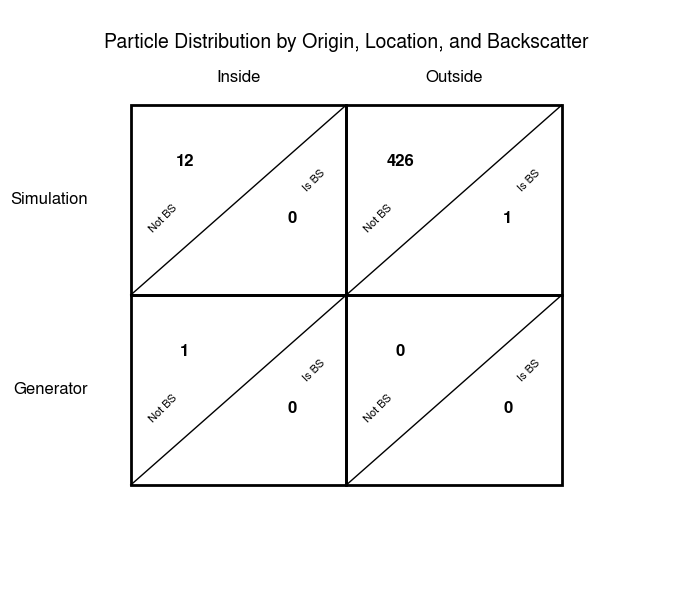

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |             1 |          0
Outside   | Generator  |             0 |          0
Inside    | Simulation |            12 |          0
Outside   | Simulation |           426 |          1

Totals by Category:
PARTICLES WITH HITS
Total particles: 440
From Generator: 1
From Simulation: 439
Inside Tracker: 13
Outside Tracker: 427
Backscatter: 1

ALL PARTICLES
Total particles: 542
From Generator: 1
From Simulation: 541
Inside Tracker: 115
Outside Tracker: 427


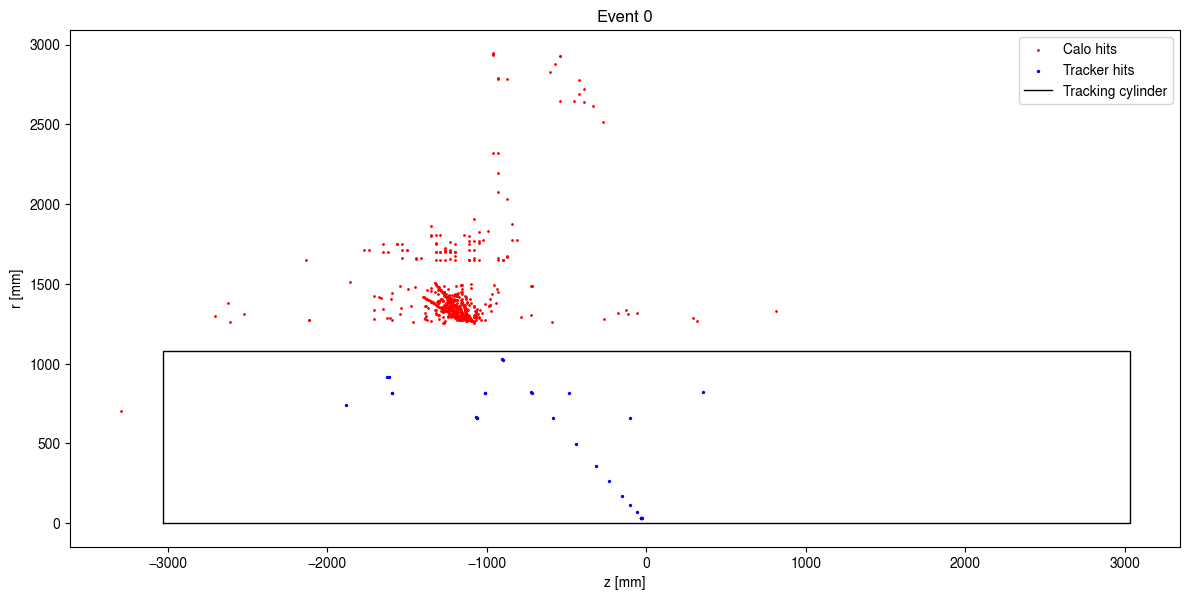

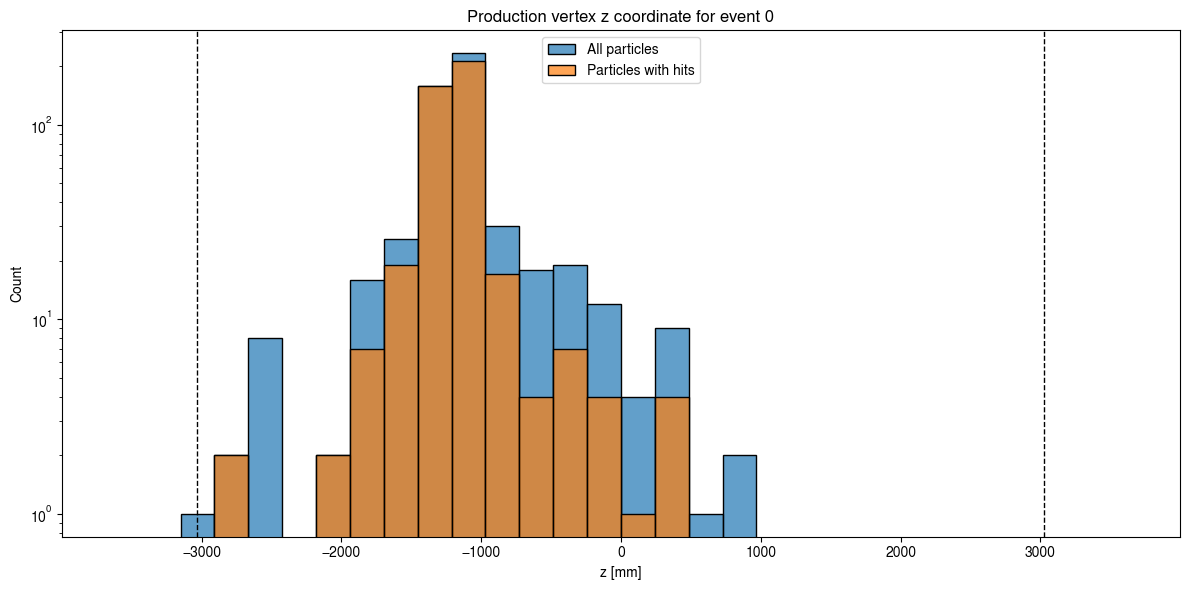

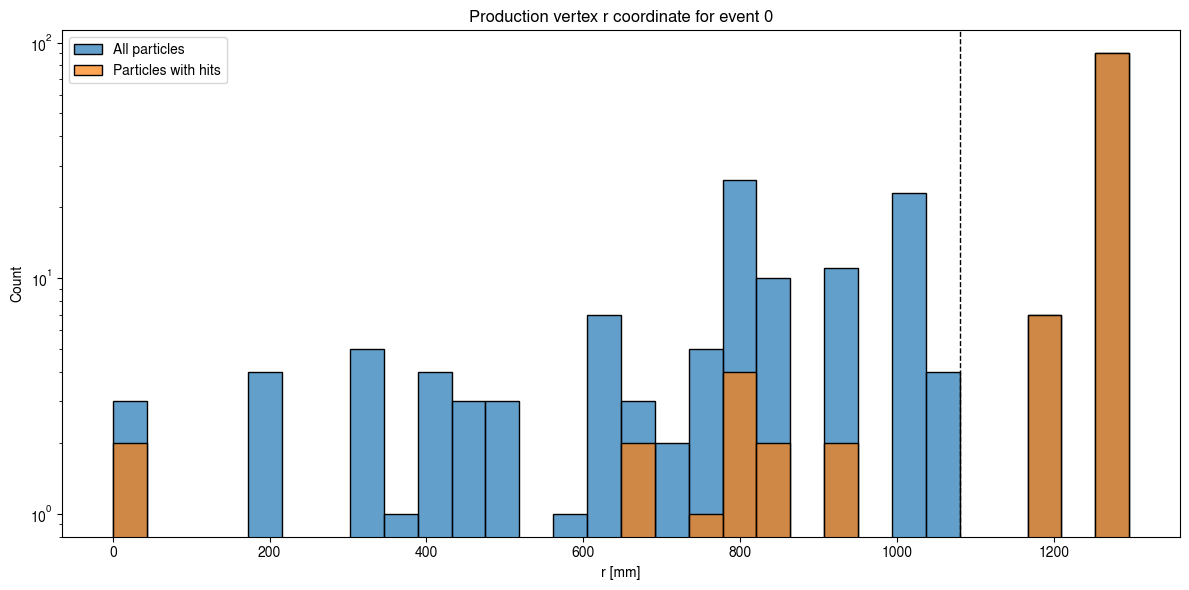

<Figure size 1200x1000 with 0 Axes>

In [24]:
plotter.event_overview()

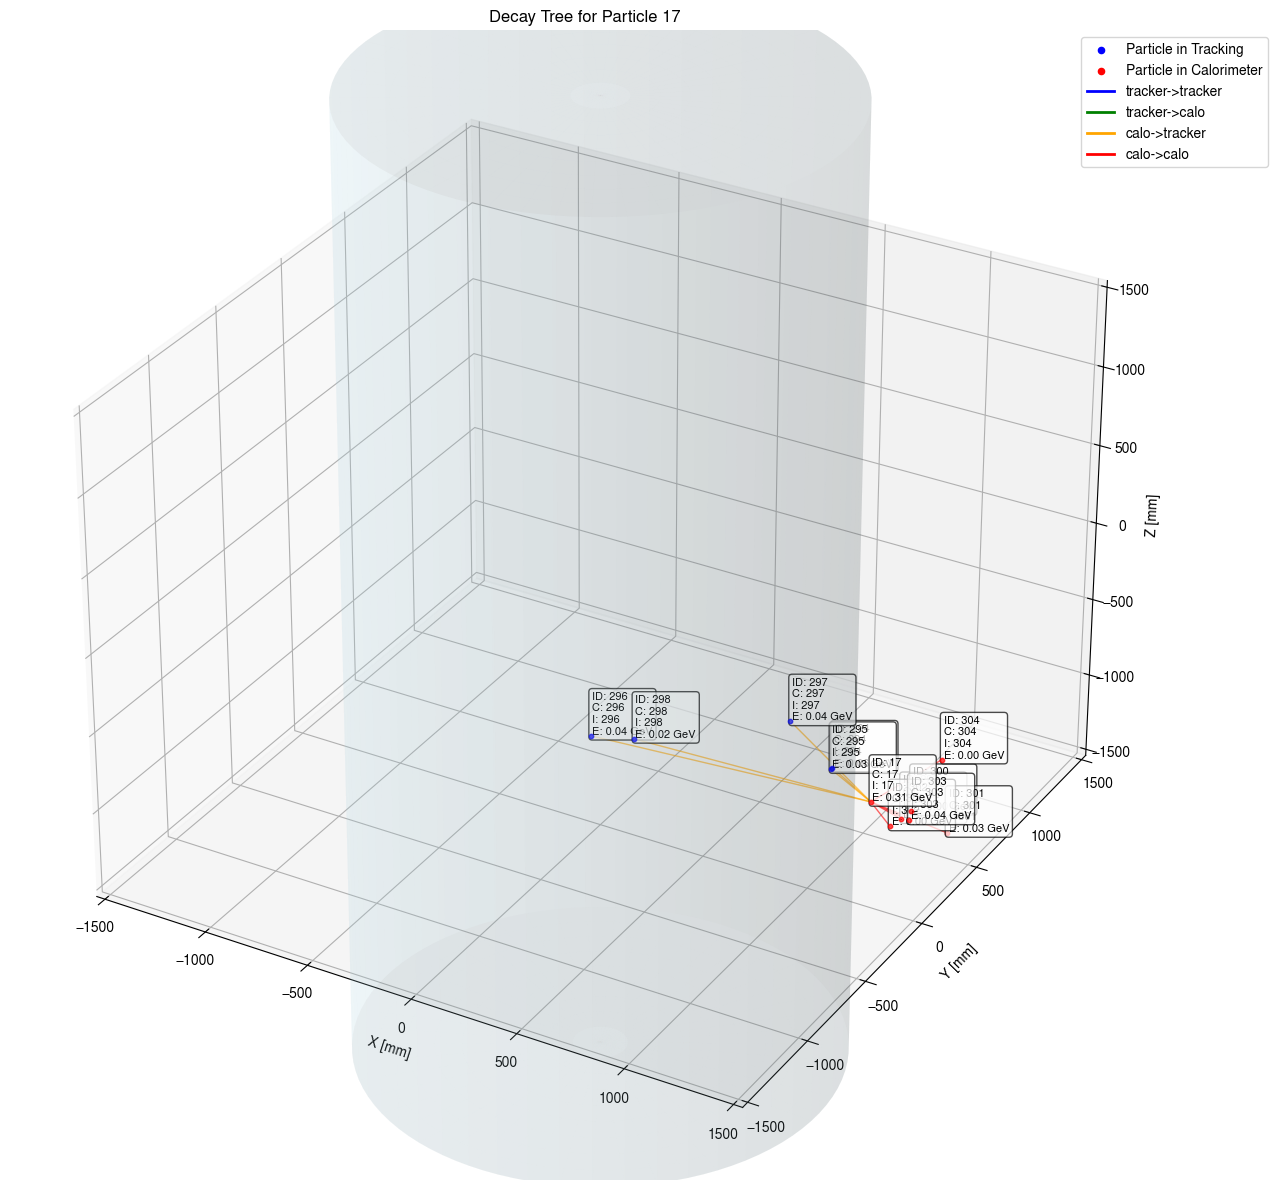

In [25]:
plot = plotter.visualize_decay_tree(particle_sample.id)

In [26]:
medium_particle = medium_event.find_matching_particle(particle_sample)

In [27]:
medium_particle

<Particle id=5 pdg=211 pT=0.26 eta=-0.59>

<Figure size 1200x1000 with 0 Axes>

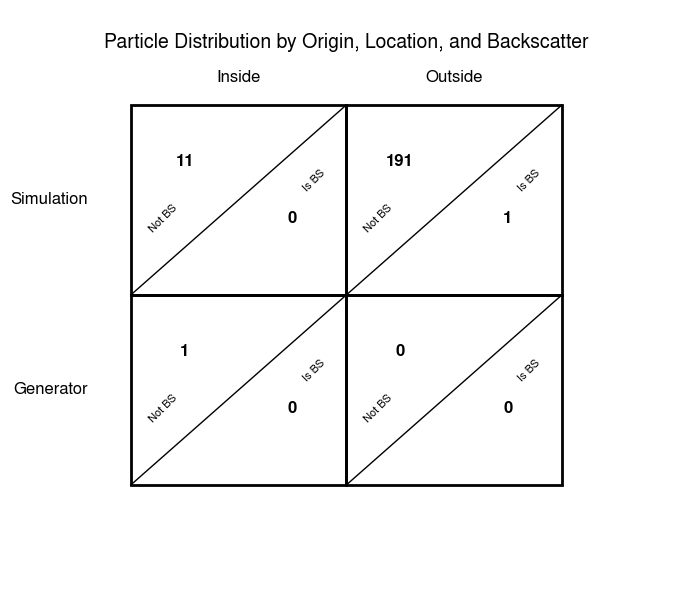

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |             1 |          0
Outside   | Generator  |             0 |          0
Inside    | Simulation |            11 |          0
Outside   | Simulation |           191 |          1

Totals by Category:
PARTICLES WITH HITS
Total particles: 204
From Generator: 1
From Simulation: 203
Inside Tracker: 12
Outside Tracker: 192
Backscatter: 1

ALL PARTICLES
Total particles: 210
From Generator: 1
From Simulation: 209
Inside Tracker: 18
Outside Tracker: 192


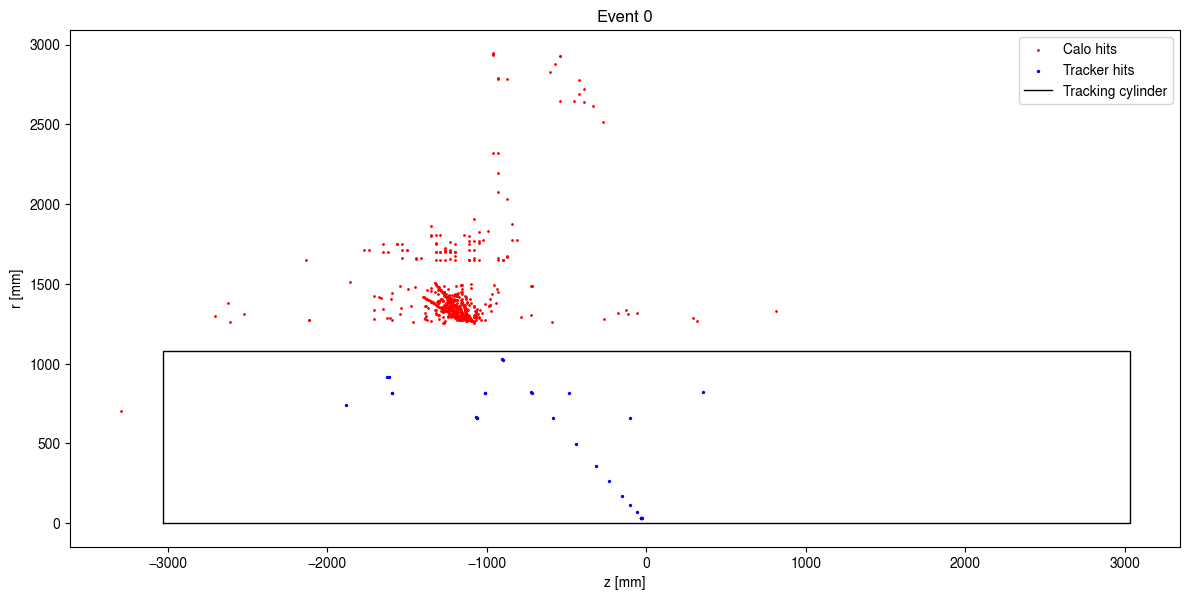

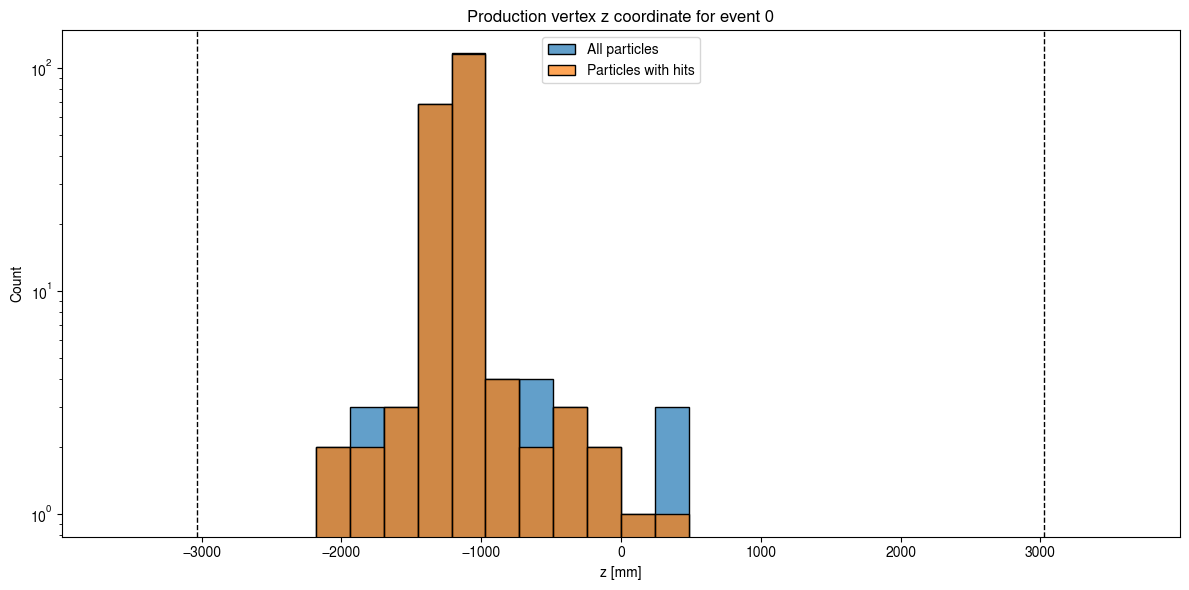

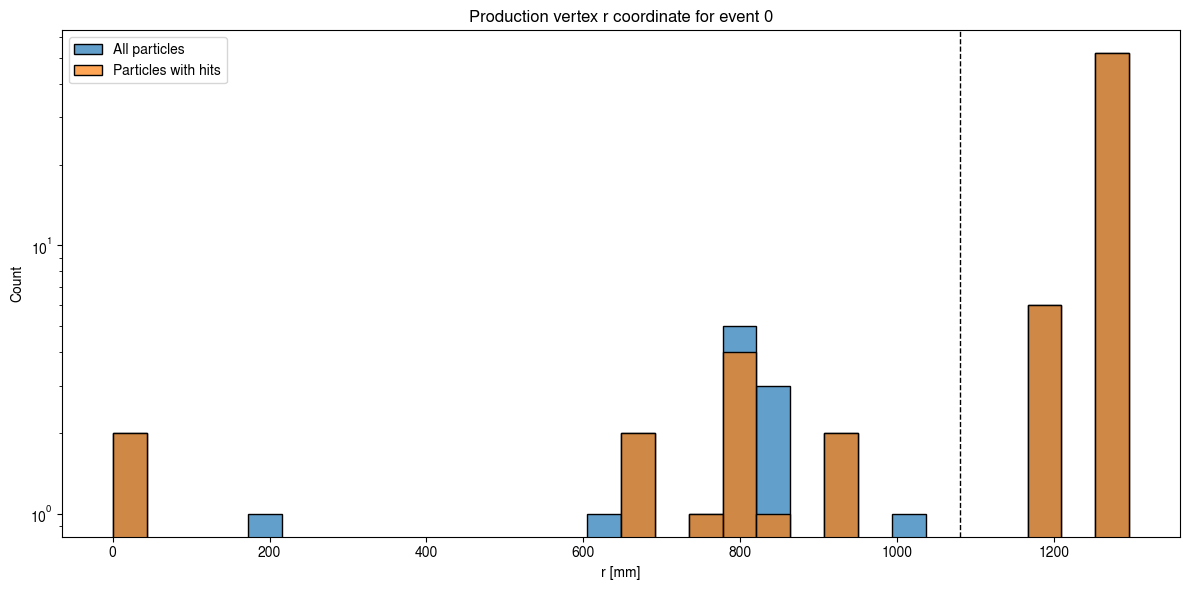

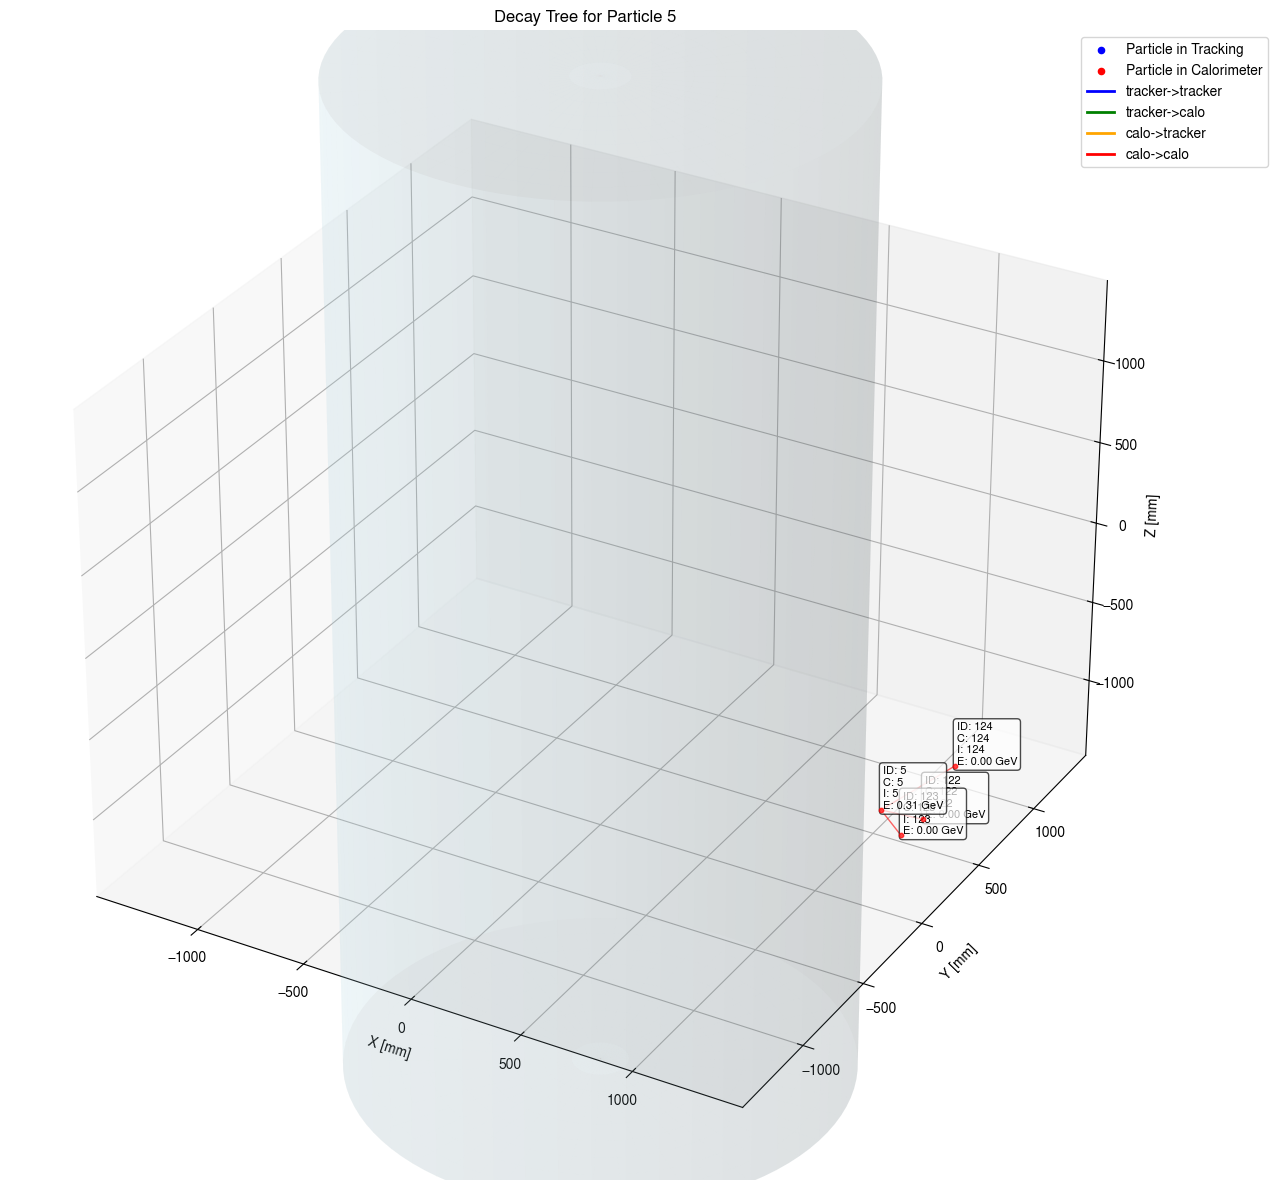

In [29]:
medium_plotter = medium_event.plot
medium_plotter.event_overview()
plot = medium_plotter.visualize_decay_tree(medium_particle.id)